# Trabalho de Introdução a Ciência de Dados - G13

In [1]:
%matplotlib inline
# Importar bibliotecas
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'svg'


In [2]:
# Carrega a sheet do arquivo excel
df_all = pd.read_excel("Dados_Sneakers_World3.xlsx", sheet_name='Sales')

### Análise Exploratória dos Dados

In [3]:
# Visão geral do DataFrame completo
print(f'Shape: {df_all.shape}')
print('\nPrimeiras linhas:')
display(df_all.head())
print('\nEstatísticas descritivas:')
display(df_all.describe())

Shape: (57780, 12)

Primeiras linhas:


,OrderNumber,ProductID,ResellerKey,EmployeeID,SalesTerritoryID,Quantity,UnitPrice,Sales,Cost,OrderDate,ShipDate,DeliveryDate
0,PV5417,17,674,141,1,2,11.019,22.038,18.719550,2023-02-18,2023-02-23,2023-03-15
1,PV7604,17,674,141,1,3,11.019,33.057,23.563031,2023-05-20,2023-05-30,2023-06-17
2,PV3568,17,638,141,1,1,11.019,11.019,9.582128,2022-11-27,2022-12-03,2022-12-14
3,PV1699,17,498,141,1,1,11.019,11.019,9.428274,2022-09-16,2022-09-17,2022-10-04
4,PV4003,17,498,141,1,10,11.019,110.190,98.119612,2022-12-16,2022-12-24,2023-01-03



Estatísticas descritivas:


,ProductID,ResellerKey,EmployeeID,SalesTerritoryID,Quantity,UnitPrice,Sales,Cost,OrderDate,ShipDate,DeliveryDate
count,57780.000000,57780.000000,57780.000000,57780.000000,57780.000000,57780.000000,57780.000000,57780.000000,57780,57780,57780
mean,214.045517,545.435981,147.647525,4.555088,3.529076,53.761489,166.137680,132.985357,2024-04-16 07:18:15.327102,2024-04-24 08:29:27.476635,2024-05-04 20:21:09.532710
min,17.000000,206.000000,141.000000,1.000000,1.000000,9.133000,9.137000,6.447017,2022-07-01 00:00:00,2022-07-03 00:00:00,2022-07-09 00:00:00
25%,131.000000,371.000000,145.000000,3.000000,2.000000,12.500000,42.482500,34.038387,2023-09-18 00:00:00,2023-09-27 00:00:00,2023-10-07 00:00:00
50%,207.000000,532.000000,147.000000,4.000000,3.000000,30.845000,85.671000,68.169068,2024-06-07 00:00:00,2024-06-17 00:00:00,2024-06-27 00:00:00
75%,296.000000,719.000000,150.000000,6.000000,4.000000,76.229000,192.958000,152.731281,2024-11-17 00:00:00,2024-11-24 00:00:00,2024-12-05 00:00:00
max,411.000000,906.000000,158.000000,10.000000,44.000000,295.601000,3333.304000,2633.457502,2025-05-31 00:00:00,2025-06-15 00:00:00,2025-07-04 00:00:00
std,113.530608,205.420978,4.472951,2.412933,3.037049,52.427990,223.636706,179.902410,NaN,NaN,NaN


In [4]:
# Diagnóstico de qualidade dos dados
print(f'Linhas duplicadas: {df_all.duplicated().sum()}')
print(f'\nValores faltantes por coluna:')
print(df_all.isna().sum())
print(f'\nLinhas completamente nulas: {(df_all.isna().all(axis=1)).sum()}')

Linhas duplicadas: 0

Valores faltantes por coluna:
OrderNumber         0
ProductID           0
ResellerKey         0
EmployeeID          0
SalesTerritoryID    0
Quantity            0
UnitPrice           0
Sales               0
Cost                0
OrderDate           0
ShipDate            0
DeliveryDate        0
dtype: int64

Linhas completamente nulas: 0


In [5]:
# Cria DF só com as variáveis de interesse
df = df_all[['Sales', 'Quantity']]


In [6]:
print(f'Shape do DataFrame filtrado: {df.shape}')
print(f'Valores nulos:\n{df.isnull().sum()}')
display(df.head())

Shape do DataFrame filtrado: (57780, 2)
Valores nulos:
Sales       0
Quantity    0
dtype: int64


,Sales,Quantity
0,22.038,2
1,33.057,3
2,11.019,1
3,11.019,1
4,110.190,10


### Medidas de posição

In [7]:
# Calcula Media, media e Moda das variáveis Sales e Quantity
medidas_posicao = pd.DataFrame({
    'Media': df.mean().round(2),
    'Mediana': df.median().round(2),
    'Moda': df.mode().iloc[0].round(2)
})
print(medidas_posicao)

           Media  Mediana   Moda
Sales     166.14    85.67  50.95
Quantity    3.53     3.00   1.00


**Interpretação:**

- **Sales:** A média e a mediana próximas indicam uma distribuição relativamente simétrica dos valores de venda. A moda representa o valor de venda mais frequente no dataset.
- **Quantity:** A média e a mediana de quantidade indicam o volume típico de itens por transação. Se a moda for menor que a média, sugere que a maioria das transações é de pequeno volume, com poucas transações grandes elevando a média.


### Medidas de Dispersão

In [8]:
# Calcula Variancia, desvio padrão e coeficiente de variação de Sales e Quantity
medidas_dispersao = pd.DataFrame({
    'Variancia': df.var().round(2),
    'Desvio Padrão': df.std().round(2),
    'CV (%)': ((df.std() / df.mean()) * 100).round(2)
})
print(medidas_dispersao)

          Variancia  Desvio Padrão  CV (%)
Sales      50013.38         223.64  134.61
Quantity       9.22           3.04   86.06


**Interpretação:**

- **Sales:** O coeficiente de variação (CV) indica o grau de dispersão relativa dos valores de venda. Um CV alto (> 30%) sugere alta variabilidade, ou seja, as vendas oscilam bastante em torno da média.
- **Quantity:** O CV da quantidade mostra se os volumes de compra são homogêneos ou heterogêneos entre as transações. Um CV menor que o de Sales indicaria que a quantidade vendida é mais consistente do que o valor monetário.


### Histograma e Boxplot

In [9]:
# Macro definições
ROTULOS = ['Sales', 'Quantity' ]
CORES = ['lightgreen','lightblue' ]
FIG_SIZE = (10,6)

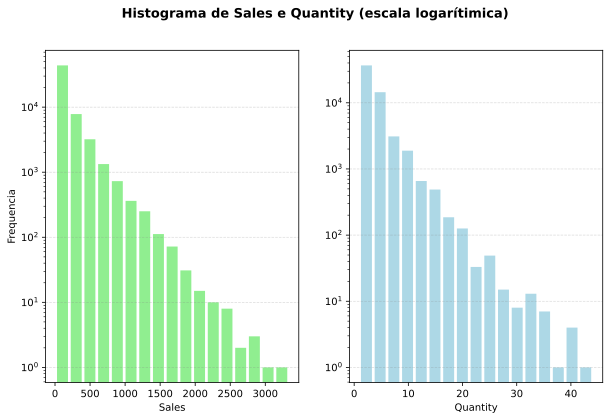

In [10]:
# Histograma
# cria figura e subplots
fig, axs = plt.subplots(1, 2, figsize=FIG_SIZE)

# estiliza para todas os subplots
for i, col in enumerate(df.columns):
    axs[i].hist(df[col], bins='sturges', color=CORES[i], rwidth=0.8, log=True)
    axs[i].set_xlabel(ROTULOS[i]) # define o rótulo da séria
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y', alpha=0.3)
    

axs[0].set_ylabel("Frequencia") # título do eixo Y apenas no gráfico da esquerda

fig.suptitle("Histograma de Sales e Quantity (escala logarítimica)", fontsize=13, fontweight='bold') # título da figura

plt.show()

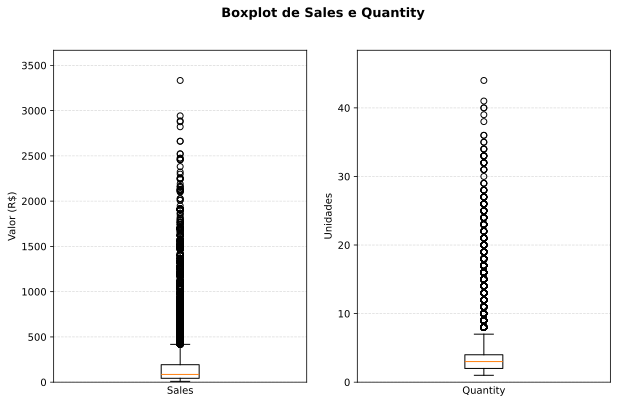

In [11]:
# Boxplots
# cria figura e subplots
fig, axs = plt.subplots(1, 2,  figsize=FIG_SIZE)

# estiliza para todas os subplots
for i, col in enumerate(df.columns):
    
    axs[i].boxplot(df[col])
    axs[i].set_xlabel(ROTULOS[i]) # define o rótulo da série
    axs[i].set_ylabel('Valor (R$)' if col == 'Sales' else 'Unidades')  # rótulo Y descritivo
    axs[i].set_facecolor('white') # cor de fundo de gráfico
    axs[i].grid(color='gray', linestyle='--', linewidth=0.7, axis='y', alpha=0.3)
    axs[i].set_xticks([])
    axs[i].set_ylim([0, df[col].max() * 1.1])


fig.suptitle("Boxplot de Sales e Quantity", fontsize=13, fontweight='bold') # título da figura

plt.show()